# Aprendizaje en línea
## Algoritmo FTL
### Ejemplo 1

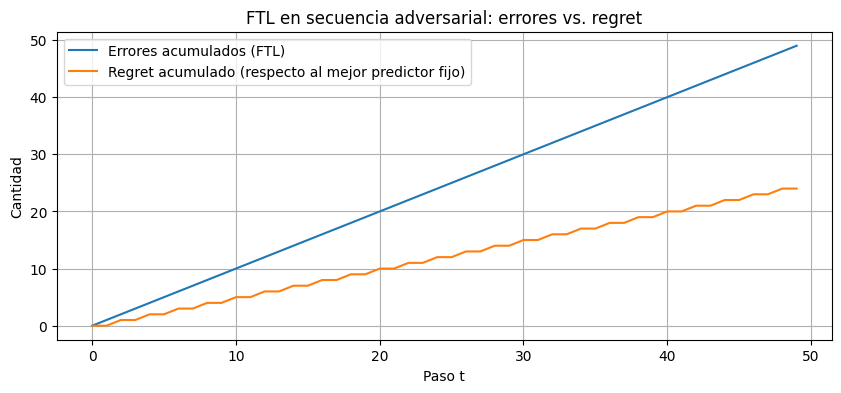

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Secuencia alternante adversarial
y = np.array([0, 1] * 25)
T = len(y)
preds = []

# FTL: predice la clase mayoritaria hasta el paso anterior
for t in range(T):
    if t == 0:
        preds.append(0)  # inicio arbitrario
    else:
        count_0 = np.sum(y[:t] == 0)
        count_1 = np.sum(y[:t] == 1)
        preds.append(0 if count_0 > count_1 else 1)

# Pérdida del algoritmo
errors = (np.array(preds) != y).astype(int)
loss_cumulative = np.cumsum(errors)

# Pérdida del mejor predictor fijo en cada paso
regret_curve = []
for t in range(1, T+1):
    loss_algo = np.sum(preds[:t] != y[:t])
    loss_best_fixed = min(np.sum(y[:t] == 1), np.sum(y[:t] == 0))
    regret_curve.append(loss_algo - loss_best_fixed)

# Visualización
plt.figure(figsize=(10, 4))
plt.plot(loss_cumulative, label="Errores acumulados (FTL)")
plt.plot(regret_curve, label="Regret acumulado (respecto al mejor predictor fijo)")
plt.xlabel("Paso t")
plt.ylabel("Cantidad")
plt.title("FTL en secuencia adversarial: errores vs. regret")
plt.grid(True)
plt.show()



### Ejemplo 2

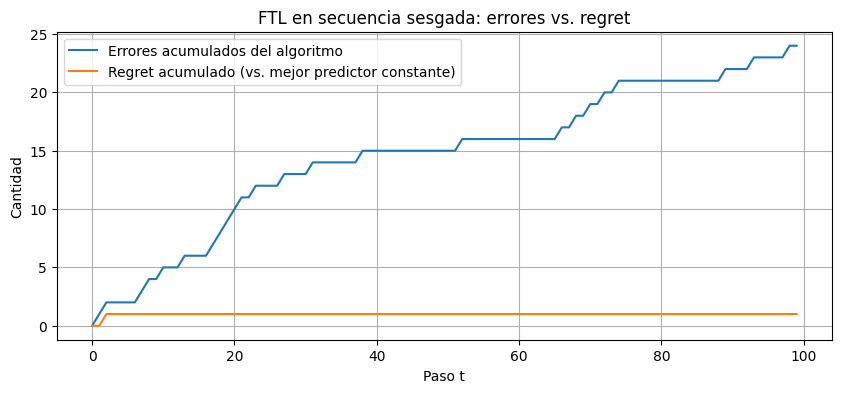

In [ ]:
np.random.seed(0)
y_biased = np.random.choice([0, 1], size=100, p=[0.7, 0.3])
T = len(y_biased)
preds_biased = []

# FTL: predice clase mayoritaria hasta t-1
for t in range(T):
    if t == 0:
        preds_biased.append(0)
    else:
        c0 = np.sum(y_biased[:t] == 0)
        c1 = np.sum(y_biased[:t] == 1)
        preds_biased.append(0 if c0 > c1 else 1)

errors_biased = (np.array(preds_biased) != y_biased).astype(int)
losses = np.cumsum(errors_biased)

# Regret acumulado real
regret_curve = []
for t in range(1, T + 1):
    loss_algo = np.sum(preds_biased[:t] != y_biased[:t])
    loss_best = min(np.sum(y_biased[:t] == 1), np.sum(y_biased[:t] == 0))
    regret_curve.append(loss_algo - loss_best)

# Visualización
plt.figure(figsize=(10, 4))
plt.plot(losses, label="Errores acumulados del algoritmo")
plt.plot(regret_curve, label="Regret acumulado (vs. mejor predictor constante)")
plt.xlabel("Paso t")
plt.ylabel("Cantidad")
plt.title("FTL en secuencia sesgada: errores vs. regret")
plt.grid(True)
plt.legend()
plt.show()



## FTRL / Online Gradient Descent
### Ejemplo 1: Clasificación logística online con OGD

Simulamos un problema de clasificación binaria con dos clases y datos en $\mathbb{R}^2$. En cada ronda se observa un ejemplo nuevo y se actualizan los pesos con un paso de OGD sobre la pérdida logística.

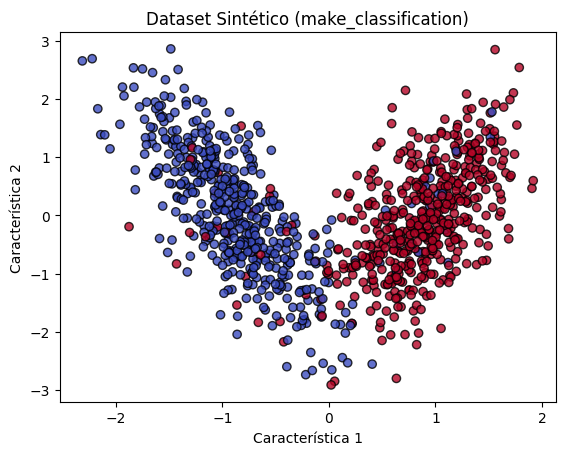

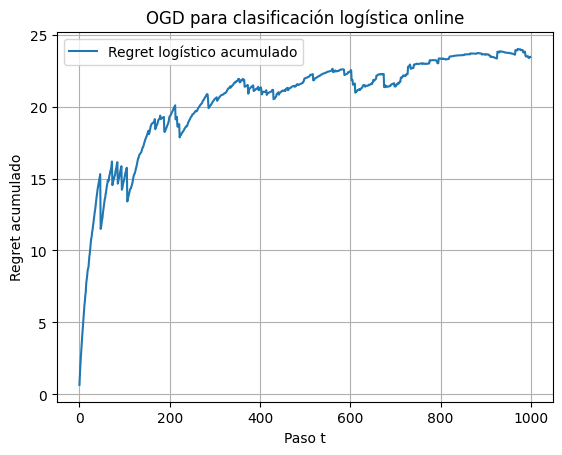

In [ ]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from scipy.special import expit

# Generamos datos secuenciales
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, flip_y=0.1,
                           class_sep=1.5, random_state=0)
X = StandardScaler().fit_transform(X)


#visualizar datos
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.8, edgecolors='k')
plt.title("Dataset Sintético (make_classification)")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()



# Funciones
def sigmoid(z):
    return expit(z)

def logistic_loss(w, x, y):
    z = np.dot(w, x)

    # Forma numéricamente estable de:
    # -y*log(sigmoid(z)) - (1-y)*log(1-sigmoid(z))
    return np.logaddexp(0, z) - y * z

def logistic_grad(w, x, y):
    z = np.dot(w, x)
    return (sigmoid(z) - y) * x


# Parámetros de OGD
eta = 0.1
B = 10.0                       # Radio del conjunto de parámetros
w = np.zeros(X.shape[1])

online_losses = []
w_hist = [w.copy()]

# OGD
for t in range(len(X)):

    # 1. Evaluar antes de actualizar
    loss_t = logistic_loss(w, X[t], y[t])
    online_losses.append(loss_t)

    # 2. Actualizar después de observar y[t]
    grad = logistic_grad(w, X[t], y[t])
    w = w - eta * grad

    # 3. Proyección sobre la bola ||w|| <= B
    norm_w = np.linalg.norm(w)

    if norm_w > B:
        w = B * w / norm_w

    w_hist.append(w.copy())


# Mejor predictor fijo en retrospectiva
def total_logistic_loss(v):
    z = X @ v
    return np.sum(np.logaddexp(0, z) - y * z)

constraint = {
    "type": "ineq",
    "fun": lambda v: B**2 - np.dot(v, v)
}

result = minimize(
    total_logistic_loss,
    x0=np.zeros(X.shape[1]),
    method="SLSQP",
    constraints=constraint
)

if not result.success:
    raise RuntimeError(result.message)

w_star = result.x

# Pérdidas del mejor predictor fijo
z_star = X @ w_star
fixed_losses = np.logaddexp(0, z_star) - y * z_star

# Regret acumulado
instantaneous_regret = np.array(online_losses) - fixed_losses
cumulative_regret = np.cumsum(instantaneous_regret)

# Gráfica
plt.plot(cumulative_regret, label="Regret logístico acumulado")
plt.xlabel("Paso t")
plt.ylabel("Regret acumulado")
plt.title("OGD para clasificación logística online")
plt.grid(True)
plt.legend()
plt.show()

### Ejemplo 2: OGD con pérdida cuadrática (regresión lineal)

En este ejemplo, aplicamos el algoritmo de Online Gradient Descent (OGD) al problema de regresión lineal en línea.

Observamos una secuencia de pares \((x_t, y_t)\), donde:
- $ x_t \in \mathbb{R} $ es una característica unidimensional,
- $ y_t = 2x_t + \varepsilon_t $ es la respuesta observada, con ruido gaussiano.

Queremos ajustar un modelo lineal $\hat{y}_t = w_t x_t $, actualizando el parámetro \( w_t \) a medida que observamos nuevos datos.

Utilizamos como función de pérdida la pérdida cuadrática:
$
\ell_t(w) = (w x_t - y_t)^2
$

La regla de actualización de OGD es:
$
w_{t+1} = w_t - \eta \cdot \nabla \ell_t(w_t), \quad
\nabla \ell_t(w_t) = 2(w_t x_t - y_t) x_t
$

Al visualizar el regret acumulado, esperamos que crezca más lentamente que el tiempo total (sublineal), lo que indicaría que el algoritmo está aprendiendo correctamente a lo largo de la secuencia.

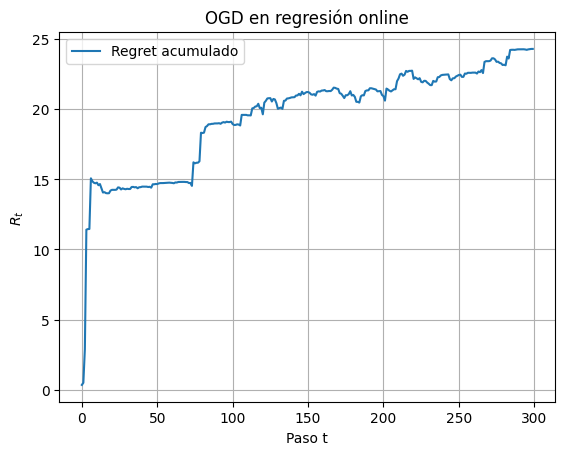

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 300
X = np.random.randn(n, 1)

true_w = 2.0
y = X.flatten() * true_w + np.random.randn(n) * 0.5

# OGD
w = np.array([0.0])
eta = 0.1

cumulative_online_loss = 0.0
online_losses = []
regret_curve = []

for t in range(n):
    x_t = X[t]
    y_t = y[t]

    # 1. Predecir antes de actualizar
    pred_t = np.dot(w, x_t)

    # 2. Sufrir la pérdida
    loss_t = (pred_t - y_t) ** 2
    online_losses.append(loss_t)
    cumulative_online_loss += loss_t

    # 3. Mejor predictor fijo para las observaciones 1,...,t
    X_prefix = X[:t + 1]
    y_prefix = y[:t + 1]

    w_star_t = np.linalg.lstsq(
        X_prefix,
        y_prefix,
        rcond=None
    )[0]

    best_fixed_loss = np.sum(
        (X_prefix @ w_star_t - y_prefix) ** 2
    )

    # 4. Regret hasta el tiempo t
    regret_t = cumulative_online_loss - best_fixed_loss
    regret_curve.append(regret_t)

    # 5. Actualizar después de observar la pérdida
    grad = 2 * (pred_t - y_t) * x_t
    w = w - eta * grad


plt.plot(regret_curve, label="Regret acumulado")
plt.xlabel("Paso t")
plt.ylabel(r"$R_t$")
plt.title("OGD en regresión online")
plt.grid(True)
plt.legend()
plt.show()


## Hedge (combinación de expertos)

### Ejemplo 1: Tres expertos fijos (uno bueno, uno malo, uno aleatorio)

📋 **Escenario**:

Simulamos un entorno donde hay tres "expertos" que predicen $y_t \in \{0, 1\}$ en cada ronda.

- El **Experto 1** acierta siempre.
- El **Experto 2** se equivoca siempre.
- El **Experto 3** predice aleatoriamente (tasa de acierto del 50%).

Usamos el algoritmo **Hedge** para combinar las predicciones de estos expertos en cada paso, actualizando sus pesos de acuerdo con su desempeño pasado.

La predicción del algoritmo en el paso $t$ se calcula como una combinación ponderada de las predicciones de los expertos:

$$
p_t = \sum_{i=1}^N q_{i,t} \cdot h_{i,t}, \quad
q_{i,t} = \frac{w_{i,t}}{\sum_{j=1}^N w_{j,t}}
$$

Donde $w_{i,t}$ es el peso del experto $i$ en el tiempo $t$.

Después de observar la respuesta verdadera $y_t$, actualizamos los pesos según:

$$
w_{i,t+1} = w_{i,t} \cdot e^{-\eta \cdot \ell(h_{i,t}, y_t)}
$$

donde $\ell(h_{i,t}, y_t)$ es la pérdida 0-1 del experto $i$ en el paso $t$.

Visualizamos el **regret acumulado** del algoritmo respecto al mejor experto (el que habría cometido menos errores si lo hubiéramos seguido siempre).


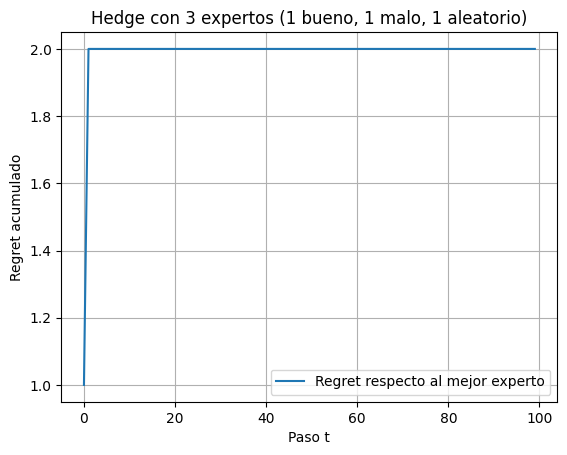

In [ ]:
np.random.seed(0)

T = 100
y = np.random.choice([0, 1], size=T)  # verdadero resultado

# Expertos:
# 1: siempre predice bien
# 2: siempre predice mal
# 3: predice aleatorio
h1 = y.copy()
h2 = 1 - y
h3 = np.random.choice([0, 1], size=T)

H = np.vstack([h1, h2, h3])  # expertos x tiempo
N = H.shape[0]

# Inicializamos pesos
eta = 0.5
w = np.ones(N)
regret = []
losses = []

for t in range(T):
    q = w / np.sum(w)
    pred = int(np.dot(q, H[:, t]) > 0.5)
    loss = int(pred != y[t])
    losses.append(loss)

    # Actualizamos pesos de expertos
    losses_experts = (H[:, t] != y[t]).astype(float)
    w *= np.exp(-eta * losses_experts)

    # Regret respecto al mejor experto
    best_loss = np.min(np.cumsum((H != y).astype(float), axis=1)[:, t])
    regret.append(np.sum(losses) - best_loss)

# Gráfica de regret
plt.plot(regret, label="Regret respecto al mejor experto")
plt.xlabel("Paso t")
plt.ylabel("Regret acumulado")
plt.title("Hedge con 3 expertos (1 bueno, 1 malo, 1 aleatorio)")
plt.grid(True)
plt.legend()
plt.show()


### Ejemplo 2: Predicción de secuencia no determinista con errores controlados

📋 **Escenario**:

Generamos una secuencia aleatoria de valores $y_t \in \{0, 1\}$, y creamos tres expertos imperfectos que intentan predecir dicha secuencia con distintos niveles de precisión:

- El **Experto 1** tiene una precisión del 90% (error del 10%).
- El **Experto 2** tiene una precisión del 80% (error del 20%).
- El **Experto 3** tiene una precisión del 60% (error del 40%).

Cada experto realiza sus predicciones agregando ruido a la secuencia verdadera, y el algoritmo **Hedge** combina sus predicciones usando pesos adaptativos.

En cada paso $t$:
- Se calcula la predicción ponderada del algoritmo:
  $$
  p_t = \sum_{i=1}^N q_{i,t} \cdot h_{i,t}, \quad
  q_{i,t} = \frac{w_{i,t}}{\sum_{j=1}^N w_{j,t}}
  $$
- Luego de observar $y_t$, se actualizan los pesos según su desempeño con pérdida 0-1:
  $$
  w_{i,t+1} = w_{i,t} \cdot e^{-\eta \cdot \ell(h_{i,t}, y_t)}
  $$

Finalmente, se visualiza el **regret acumulado** del algoritmo respecto al mejor experto en retrospectiva.


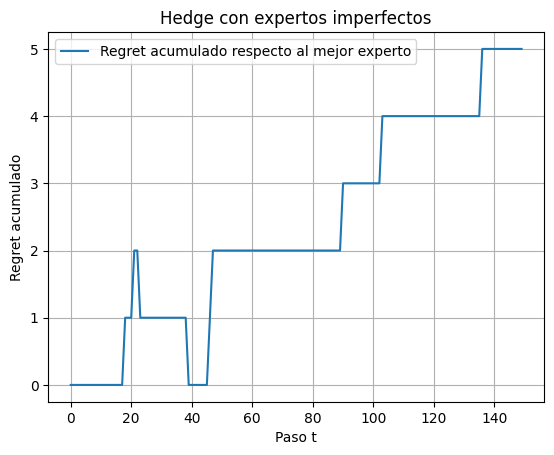

In [ ]:
np.random.seed(1)
T = 150
y = np.random.choice([0, 1], size=T)

# Expertos con distintas tasas de error
def noisy_copy(y, error_rate):
    flips = np.random.rand(len(y)) < error_rate
    return np.where(flips, 1 - y, y)

H = np.vstack([
    noisy_copy(y, 0.1),  # experto 1: 90% accuracy
    noisy_copy(y, 0.2),  # experto 2: 80% accuracy
    noisy_copy(y, 0.4),  # experto 3: 60% accuracy
])
N = H.shape[0]

w = np.ones(N)
losses = []
regret = []

for t in range(T):
    q = w / np.sum(w)
    pred = int(np.dot(q, H[:, t]) > 0.5)
    loss = int(pred != y[t])
    losses.append(loss)

    losses_experts = (H[:, t] != y[t]).astype(float)
    w *= np.exp(-eta * losses_experts)

    best_loss = np.min(np.cumsum((H != y).astype(float), axis=1)[:, t])
    regret.append(np.sum(losses) - best_loss)

plt.plot(regret, label="Regret acumulado respecto al mejor experto")
plt.xlabel("Paso t")
plt.ylabel("Regret acumulado")
plt.title("Hedge con expertos imperfectos")
plt.grid(True)
plt.legend()
plt.show()


# Trabajo en clase

Vamos a usar una base de datos de rentas de bicicletas por hora `Bike Sharing Demand` disponible en Scikit-learn. Tenemos datos de la forma

$$(x_t, y_t),$$

donde $x_t$ es un vector de características, $y_t$ el número de biciletas rentadas al tiempo $t$. Aplicar el algoritmo *Online Gradient Descent* a esta base de datos y evaluar su Regret.

1. Descripción del problema
2. Metodología
3. Resultados, tablas, gráficas
4. Conclusiones